#Sentiment Analysis using NLP

## **Problem Statement**

Perform sentiment analysis on IMDb movie reviews to classify reviews as positive or negative using NLP techniques.

## **Importing Libraries**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords

## **Loading the dataset**

In [10]:
df = pd.read_csv('/content/IMDB_Dataset.csv')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


## **Data Understanding**

In [11]:
#load first 5rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [14]:
#size of dataset
df.shape

(50000, 2)

In [16]:
#data set info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [15]:
#count of each sentiments
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


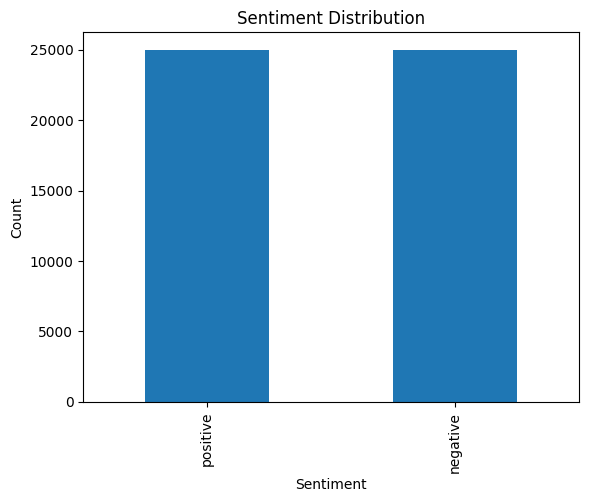

In [19]:
#sentiment distribution visualization
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

The dataset contains 50,000 movie reviews labeled as positive or negative.
The dataset is balanced with 25,000 reviews in each class.

## **Data Cleaning and Preprocessing**

In [22]:
#standarizing to lower case
df['review'] = df['review'].str.lower()
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [15]:
#find latest date
df[df['date'] == '2017-08-15']

,id,date,store_nbr,family,sales,onpromotion


In [24]:
#removing html tags
df['review'] = df['review'].apply(lambda x : re.sub(r'<.*?>', '', x))

In [30]:
#removing punctuation
df['review'] = df['review'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

In [31]:
#checking if cleaning worked properly
df['review'].iloc[0]

'one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictur

In [33]:
#Remove Stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['review'] = df['review'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [34]:
#rechecking
df['review'].iloc[0]

'one reviewers mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awayi would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle 

In [35]:
#Lemmatization: reducing words to their root form
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df['review'] = df['review'].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [36]:
#rechecking
df['review'].iloc[0]

'one reviewer mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home manyaryans muslim gangsta latino christian italian irish moreso scuffle death stare dodgy dealing shady agreement never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture painted mainstream audience forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard wholl sold nickel inmate wholl kill order get away well mannered middle class inmate turned prison b

In [37]:
#Converting Text to TF-IDF (TF = Term Frequency, IDF = Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['review'])

## Feature Engineering: TF-IDF

Why Not CountVectorizer?

CountVectorizer simply counts how many times each word appears in a review.
However, common words like movie, film, or story may appear frequently in many reviews but do not strongly indicate sentiment. Pure word counts may give unnecessary importance to such generic terms.

`

Why TF-IDF?
 (Term Frequency – Inverse Document Frequency):

Increases weight for words that appear frequently in a specific review

Reduces weight for words that appear in many reviews

This helps highlight strong sentiment words like excellent, terrible, amazing, or boring, making TF-IDF more effective for classification tasks.

In [38]:
#checking no of rows & cols
X.shape

(50000, 5000)

After applying TF-IDF, the dataset becomes a matrix of shape:

(50000, 5000)

This means:

50,000 reviews

5,000 word features

Each review contains only a small number of these words, so most values are 0.
This results in a high-dimensional sparse matrix, which is common in text data and works well with models like Logistic Regression and Naive Bayes.

In [39]:
#Converting Sentiment Labels to Numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['sentiment'])

In [40]:
y[:10]

array([1, 1, 1, 0, 1, 1, 1, 0, 0, 1])

In [41]:
le.classes_

array(['negative', 'positive'], dtype=object)

## **Train-Test Split**

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
X_train.shape

(40000, 5000)

In [50]:
X_test.shape

(10000, 5000)

In [44]:
#Building First Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [45]:
#After training, predicting:
y_pred = model.predict(X_test)

In [51]:
#Evaluating Model
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8867
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



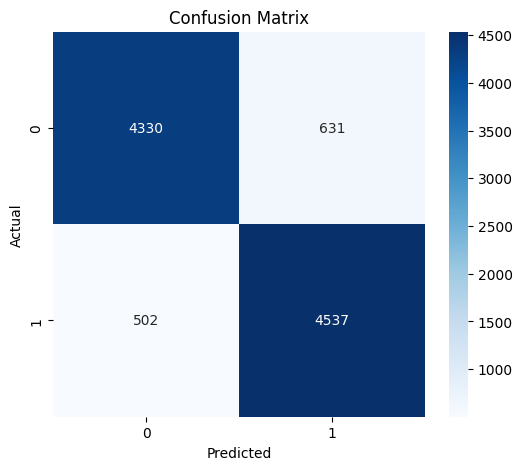

In [52]:
#Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [53]:
#Comparing with Naive Bayes:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.852
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



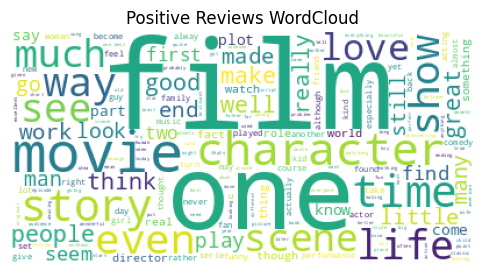

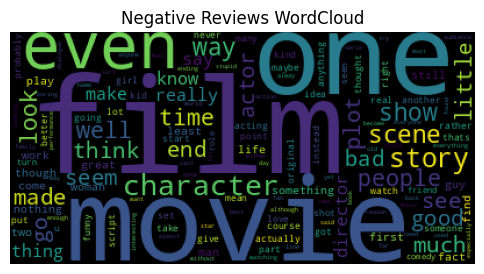

In [55]:
#WordCloud for Positive and Negative Reviews
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df[df['sentiment']=='positive']['review'])
negative_text = " ".join(df[df['sentiment']=='negative']['review'])

# Positive WordCloud
plt.figure(figsize=(6,5))
wc_pos = WordCloud(background_color='white').generate(positive_text)
plt.imshow(wc_pos)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

# Negative WordCloud
plt.figure(figsize=(6,5))
wc_neg = WordCloud(background_color='black').generate(negative_text)
plt.imshow(wc_neg)
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

## Model Comparison

In [54]:
#Adding Model Comparison Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [0.8867, 0.852]
})

results

,Model,Accuracy
0,Logistic Regression,0.8867
1,Naive Bayes,0.8520


## **Business Insights**

*   The dataset contains an equal distribution of positive and negative reviews, ensuring unbiased model training.
*  Logistic Regression achieved the highest accuracy (88.67%), making it the preferred model.
*   Both models demonstrated balanced precision and recall, indicating stable performance.
*   The model can be used by movie platforms to automatically classify user reviews.
*   Negative reviews can be flagged for further analysis to improve user experience.

## **Conclusion**

In this project, sentiment analysis was performed on IMDb movie reviews using NLP techniques.
Text preprocessing steps such as lowercasing, stopword removal, and lemmatization improved text quality. TF-IDF was used for feature extraction. Logistic Regression outperformed Naive Bayes, achieving 88.67% accuracy.

This model can be applied in real-world applications such as customer feedback analysis and brand monitoring.